# Student Lifestyle & Academic Performance

#### *Does sleeping more lead to a better GPA?*

**Author:** Abdoul Salma  
**Stack:** Python · pandas · seaborn · matplotlib

## Overview

Modern student life is increasingly defined by the challenge of balancing personal habits with intense academic expectations. With university culture often celebrating long hours, constant connectivity, and maximum productivity, many students build routines centered around academic achievement at the cost of lifestyle stability. Sleep, exercise, social engagement, and extracurricular involvement are commonly regarded as important components for mental well-being, but their direct influence on grades is widely debated. Understanding how these lifestyle factors interact with emotional strain and academic results can help students and educators better recognize patterns that support both well-being and performance.

This analysis uses survey data collected via Google Form over one academic year (August 2023–May 2024) from university students, primarily in India. Each record includes self-reported daily hours for study, extracurricular involvement, socializing, sleep, and physical activity, along with stress level and CGPA.

The central question: **Do students who trade sleep for study time achieve better GPAs—and at what cost to their stress levels?** Because the dataset does not measure emotions directly, self-reported stress serves as a proxy for emotional strain. The analysis maps how daily routines relate to stress and CGPA, and whether high academic outcomes require meaningful lifestyle trade-offs.

![image.png](attachment:image.png)

*Image source: https://assets.clevelandclinic.org/transform/LargeFeatureImage/c96c06fc-09f7-49ca-a758-5e3700ec3b0f/college-Students-mental-health1-1397488501-770x533-1_jpg*

## Data & Methods
### Data Source



Data comes from the [Daily Lifestyle and Academic Performance of Students](https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset/data) dataset on Kaggle.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

In [2]:
# Load the dataset
df = pd.read_csv("Daily_Lifestyle_and_Academic_Performance.csv")

### Data Preparation

Column names were standardized for analysis. Stress levels were encoded numerically (Low = 1, Moderate = 2, High = 3), and student ID was set as the index so it would not be treated as an analytic variable.

In [3]:
# Rename columns
df.columns = [
    "student_id",
    "study",
    "extras",
    "sleep",
    "social",
    "activity",
    "cgpa",
    "stress",
]
# Set student_id as index 
df = df.set_index("student_id")
# Convert stress levels to numeric values
df = df.replace({"stress": {"Low": 1, "Moderate": 2, "High": 3}})


C:\Users\abdou\AppData\Local\Temp\ipykernel_32312\2578966692.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"stress": {"Low": 1, "Moderate": 2, "High": 3}})


## Analysis

The sections below examine relationships between sleep, stress, study hours, CGPA, and physical activity.

### Stress Level Distribution

Most students in the sample report moderate to high stress, with high stress being the most common category.

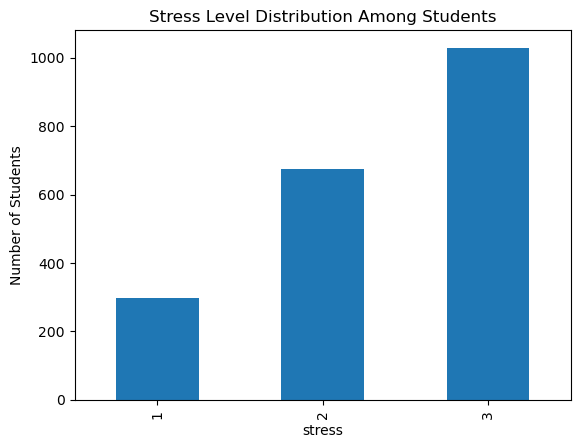

In [4]:
df["stress"].value_counts().sort_index().plot(kind="bar")
plt.title("Stress Level Distribution Among Students")
plt.ylabel("Number of Students")
plt.show()

### Distribution of Sleep

Sleep distribution shows how students allocate rest across a typical day.

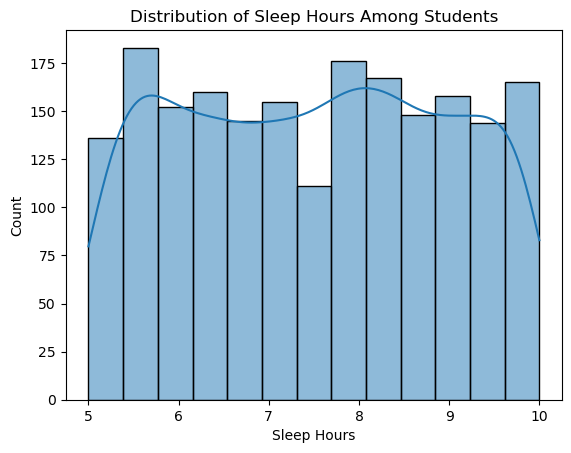

In [5]:
sns.histplot(data=df, x="sleep", kde=True)
plt.title("Distribution of Sleep Hours Among Students")
plt.xlabel("Sleep Hours")
plt.show()

In [6]:
# percent < 7 hours of sleep
count_lt7 = df[df["sleep"] < 7].shape[0]
percent_lt7 = count_lt7 / len(df) * 100

# percent 7–9 hours of sleep
count_7_9 = df[(df["sleep"] >= 7) & (df["sleep"] <= 9)].shape[0]
percent_7_9 = count_7_9 / len(df) * 100

# percent > 9 hours of sleep
count_gt9 = df[df["sleep"] > 9].shape[0]
percent_gt9 = count_gt9 / len(df) * 100

#print results
print(f"<7 hours: {percent_lt7:.1f}%")
print(f"7–9 hours: {percent_7_9:.1f}%")
print(f">9 hours: {percent_gt9:.1f}%")

<7 hours: 38.8%
7–9 hours: 41.9%
>9 hours: 19.3%


A substantial share of students fall outside the recommended 7–9 hours of sleep—38.8% report fewer than 7 hours. The next step is to test whether short sleep shows up in academic outcomes.

### Sleep and CGPA

Sleep duration shows little linear relationship with CGPA.

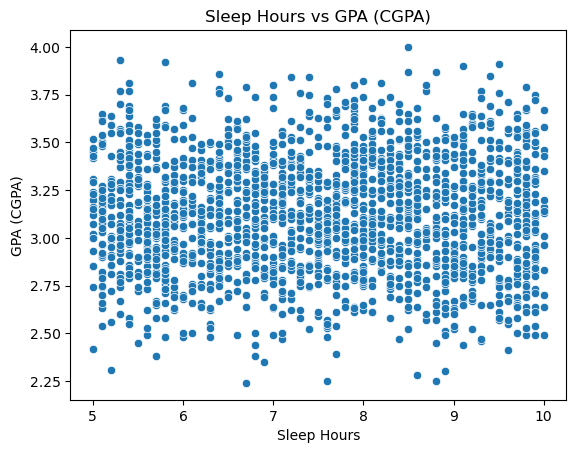

In [7]:
sns.scatterplot(data=df, x="sleep", y="cgpa")
plt.title("Sleep Hours vs GPA (CGPA)")
plt.xlabel("Sleep Hours")
plt.ylabel("GPA (CGPA)")
plt.show()

### Stress Level by Sleep Group

Students sleeping fewer than 7 hours report higher average stress than those in the 7–9 hour range.

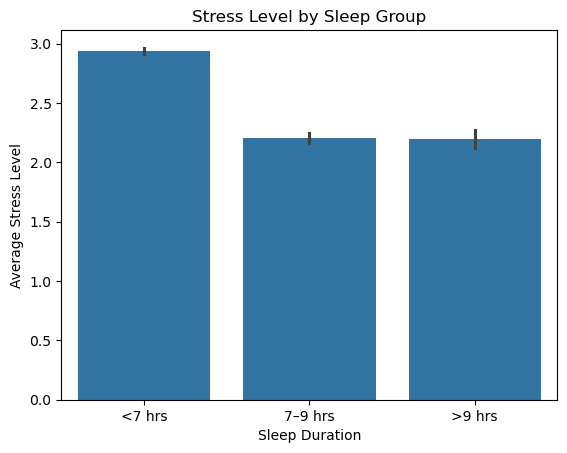

In [8]:
df_plot = df.copy()

# If stress is encoded 1=Low, 2=Moderate, 3=High, make sleep groups
df_plot["sleep_group"] = pd.cut(
    df_plot["sleep"],
    bins=[0, 6, 9, 24],
    labels=["<7 hrs", "7–9 hrs", ">9 hrs"]
)

# Plot stress by sleep groups
sns.barplot(data=df_plot, x="sleep_group", y="stress")
plt.title("Stress Level by Sleep Group")
plt.xlabel("Sleep Duration")
plt.ylabel("Average Stress Level")
plt.show()

### Study Hours and Stress Level

Higher stress levels tend to coincide with more daily study hours.

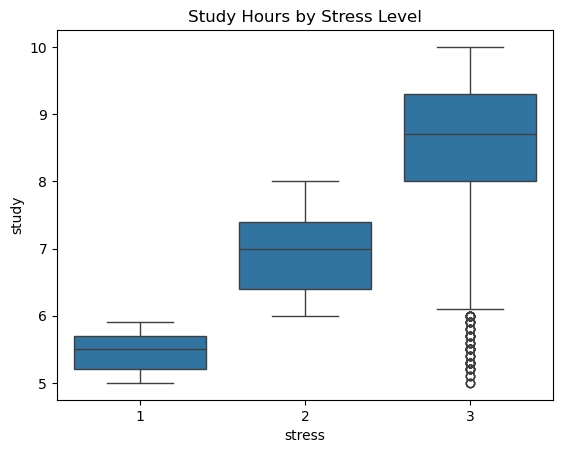

In [9]:
sns.boxplot(data=df, x="stress", y="study")
plt.title("Study Hours by Stress Level")
plt.show()

### Study hours and CGPA

Study hours show a clearer positive association with CGPA than sleep duration does.

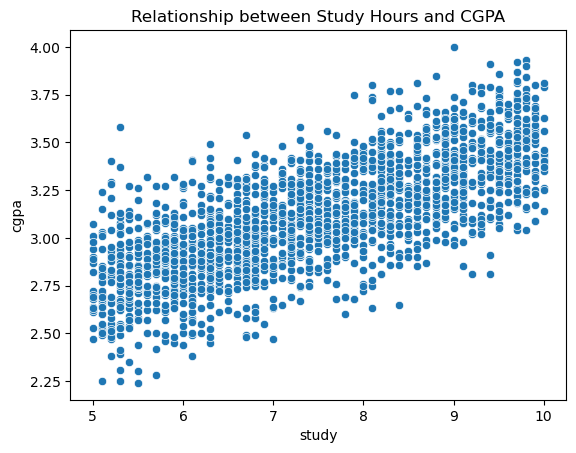

In [10]:
sns.scatterplot(data=df, x="study", y="cgpa")
plt.title("Relationship between Study Hours and CGPA")
plt.show()

### Stress & CGPA

Higher CGPA ranges coincide with higher reported stress on average.

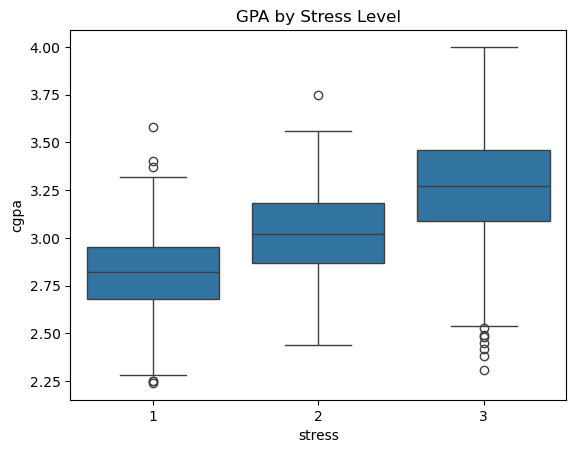

In [11]:
sns.boxplot(data=df, x="stress", y="cgpa")
plt.title("GPA by Stress Level")
plt.show()

Average stress by CGPA tier and sleep group:

In [12]:
df["gpa_group"] = pd.cut(df["cgpa"], bins=[2,2.7,3.4,4], labels=["2–2.7","2.71–3.4","3.41–4"])
df["sleep_group"] = pd.cut(df["sleep"], bins=[0,7,9,24], labels=["<7","7–9",">9"])

df.groupby(["gpa_group","sleep_group"])["stress"].mean()

grouped = (
    df.groupby(["gpa_group", "sleep_group"], observed=True)["stress"]
      .mean()
      .unstack()          
      .round(2)           
)

display(grouped)



C:\Users\abdou\AppData\Local\Temp\ipykernel_32312\1817605679.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["gpa_group","sleep_group"])["stress"].mean()


sleep_group,<7,7–9,>9
gpa_group,,,
2–2.7,2.15,1.34,1.40
2.71–3.4,2.56,2.13,2.14
3.41–4,2.94,2.90,2.89


The highest-stress profile combines top-tier CGPA with less than 7 hours of sleep (mean stress: 2.94).

### Physical activity and Stress

Higher physical activity is associated with modestly lower average stress.

In [13]:
# Group physical activity into ranges
df["activity_group"] = pd.cut(
    df["activity"],
    bins=[0, 2, 5, 14],          # you can tweak these if you like
    labels=["0–2 hrs", "2.01–5 hrs", "5.01–14 hrs"]
)

# Average stress by activity group
grouped_activity = (
    df.groupby("activity_group", observed=True)["stress"]
      .mean()
      .round(2)
      .to_frame()
)

display(grouped_activity)


,stress
activity_group,
0–2 hrs,2.63
2.01–5 hrs,2.37
5.01–14 hrs,2.21


## Summary

The analysis tested whether sacrificing sleep for study time leads to better GPAs. Sleep alone was not the strongest driver of academic performance—daily study hours showed the clearest association with CGPA. That said, sleep still mattered for well-being: students in the 7–9 hour range reported lower average stress than those sleeping less. Physical activity showed a similar, smaller effect on stress.

The trade-off is most visible at the top of the GPA distribution. Students in the highest CGPA tier tended to study the most, sleep less than 7 hours, and report the highest stress. Strong academic outcomes in this sample often came with lifestyle costs—but sleep and exercise still appear to buffer stress, even when grades are high.

**Limitations:** All variables are self-reported survey data from a single geographic sample. Findings describe associations, not causation.

## Data Sources & Tools

- **Dataset:** [Daily Lifestyle and Academic Performance of Students](https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset/data) (Kaggle)
- **pandas** — data manipulation
- **seaborn** — statistical visualization
- **matplotlib** — plotting